# PINNs: ODE damped oscillator

$$
\begin{cases}
    0 = \ddot{x} + 2\zeta\omega.\dot{x} + \omega^2.x \\
    x(0) = x_0 \\
    \dot{x}(0) = 0
\end{cases}
$$

Solution: (underdamped, $\zeta < 1$)



In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:


# Define the PINN model
class PINN(nn.Module):

    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

        # equation parameters
        self.ZETTA = 0.2
        self.W = 10

    def forward(self, t):
        return self.net(t)

    # Define the Poisson equation loss function
    def damped_oscillatior_loss(self, t):
        # alias to simplify notation
        # parameters
        ZETTA = self.ZETTA
        W = self.W
        
        # compute estimation for position
        x = self.forward(t)

        # compute derivatives of first and second order
        x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

        # residue for damped oscillator
        f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2
        return torch.mean(f)
    
    def boundary_condition_loss(self, t0, x0, dx0):

        # estimation for x0
        x0_est = self.forward(t0)

        # residue for x0
        initial_conditions = (x0_est - x0)**2

        # estimation for dx0
        dx0_est = torch.autograd.grad(x0_est, t0, grad_outputs=torch.ones_like(x0_est), create_graph=True)[0]

        # residue for dx0
        initial_conditions_der = (dx0_est - dx0)**2


        return torch.mean(initial_conditions) + torch.mean(initial_conditions_der)


    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)
    
# Define general NN model with same architecture as PINN
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)


In [3]:
# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 2]
t.requires_grad = True

# initial conditions
t0 = torch.tensor([0.0], requires_grad=True)
x0 = torch.tensor([1.0], requires_grad=True)
dx0 = torch.tensor([0.0], requires_grad=True)

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

# loss tracking
losses = []

# labeled training data
# random training data
t_sample = 1*torch.rand(100, 1)
t_sample.requires_grad = False

# convenient alias
Z = model.ZETTA
w = model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample = x0*torch.exp(-w*Z*t_sample)*(torch.cosh(w*root*t_sample) + (Z/root)*torch.sinh(w*root*t_sample))
x_sample = x_sample.real # get rid of aprox. complex values
x_sample = x_sample.detach()

# Training loop
epochs = 80000
for epoch in range(epochs):
    optimizer.zero_grad()

    x_est = model(t_sample)
    
    # Compute the loss
    loss = model.damped_oscillatior_loss(t) + model.boundary_condition_loss(t0, x0, dx0) + model.data_loss(x_sample, x_est)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/80000], Loss: 147.2177276611328
Epoch [1000/80000], Loss: 1.1440825462341309
Epoch [2000/80000], Loss: 1.1439615488052368
Epoch [3000/80000], Loss: 1.1438872814178467
Epoch [4000/80000], Loss: 1.1438393592834473
Epoch [5000/80000], Loss: 1.1438217163085938
Epoch [6000/80000], Loss: 1.1437568664550781
Epoch [7000/80000], Loss: 1.1437318325042725
Epoch [8000/80000], Loss: 1.1438252925872803
Epoch [9000/80000], Loss: 1.1437547206878662
Epoch [10000/80000], Loss: 1.1437968015670776
Epoch [11000/80000], Loss: 1.143746256828308
Epoch [12000/80000], Loss: 1.1437242031097412
Epoch [13000/80000], Loss: 1.143775463104248
Epoch [14000/80000], Loss: 1.1477909088134766
Epoch [15000/80000], Loss: 1.1439039707183838
Epoch [16000/80000], Loss: 1.143795371055603
Epoch [17000/80000], Loss: 1.1438899040222168
Epoch [18000/80000], Loss: 1.1440597772598267
Epoch [19000/80000], Loss: 1.1436529159545898
Epoch [20000/80000], Loss: 1.1436187028884888
Epoch [21000/80000], Loss: 1.1439898014068604
Epoch

In [4]:
# Create PINN nn_model
nn_model = PINN()

optimizer = optim.Adam(params=nn_model.parameters(), lr=1e-3)

# loss tracking
nn_losses = []

# labeled training data
# random training data
t_sample = 1*torch.rand(100, 1)
t_sample.requires_grad = False

# convenient alias
Z = nn_model.ZETTA
w = nn_model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample = x0*torch.exp(-w*Z*t_sample)*(torch.cosh(w*root*t_sample) + (Z/root)*torch.sinh(w*root*t_sample))
x_sample = x_sample.real # get rid of aprox. complex values
x_sample = x_sample.detach()

# Training loop
epochs = 80000
for epoch in range(epochs):
    optimizer.zero_grad()

    x_est = nn_model(t_sample)
    
    # Compute the loss
    loss = nn_model.data_loss(x_sample, x_est)
    
    # Backpropagation
    loss.backward()
    nn_losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/80000], Loss: 0.2136722058057785
Epoch [1000/80000], Loss: 0.00018351836479268968
Epoch [2000/80000], Loss: 3.37885576300323e-05
Epoch [3000/80000], Loss: 1.662877548369579e-05
Epoch [4000/80000], Loss: 0.0004966866690665483
Epoch [5000/80000], Loss: 1.1065974831581116e-05
Epoch [6000/80000], Loss: 2.1396637748694047e-05
Epoch [7000/80000], Loss: 0.00014600303256884217
Epoch [8000/80000], Loss: 8.662160325911827e-06
Epoch [9000/80000], Loss: 0.000298999686492607
Epoch [10000/80000], Loss: 4.527351848082617e-06
Epoch [11000/80000], Loss: 5.289679847919615e-06
Epoch [12000/80000], Loss: 4.510538474278292e-06
Epoch [13000/80000], Loss: 2.6078344035340706e-06
Epoch [14000/80000], Loss: 2.2928836642677197e-06
Epoch [15000/80000], Loss: 1.8876038438975229e-06
Epoch [16000/80000], Loss: 1.554372715872887e-06
Epoch [17000/80000], Loss: 5.264149513095617e-05
Epoch [18000/80000], Loss: 1.173624968942022e-05
Epoch [19000/80000], Loss: 3.1100059914024314e-06
Epoch [20000/80000], Loss: 7.9

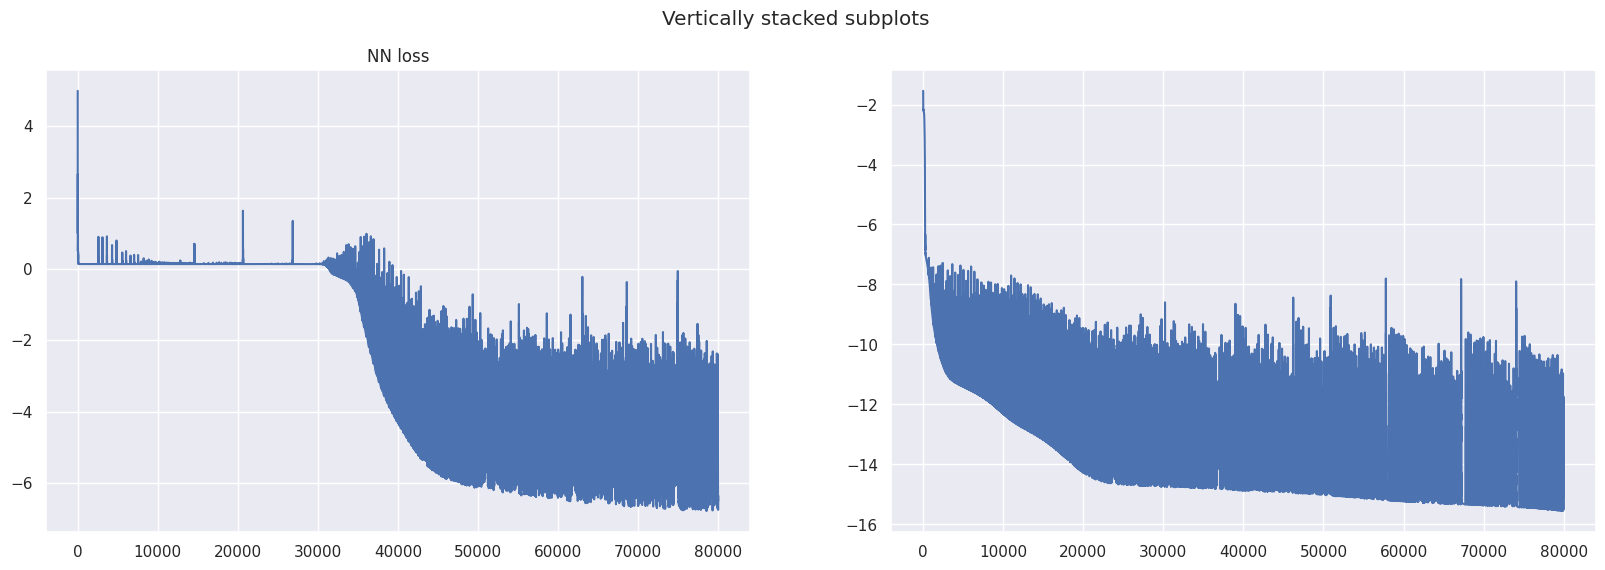

In [5]:
fig, axs = plt.subplots(1,2, figsize=(20,6))
axs[0].plot(losses)
axs[1].plot(nn_losses)
axs[0].set_title("PNN loss")
axs[0].set_title("NN loss")
fig.show()

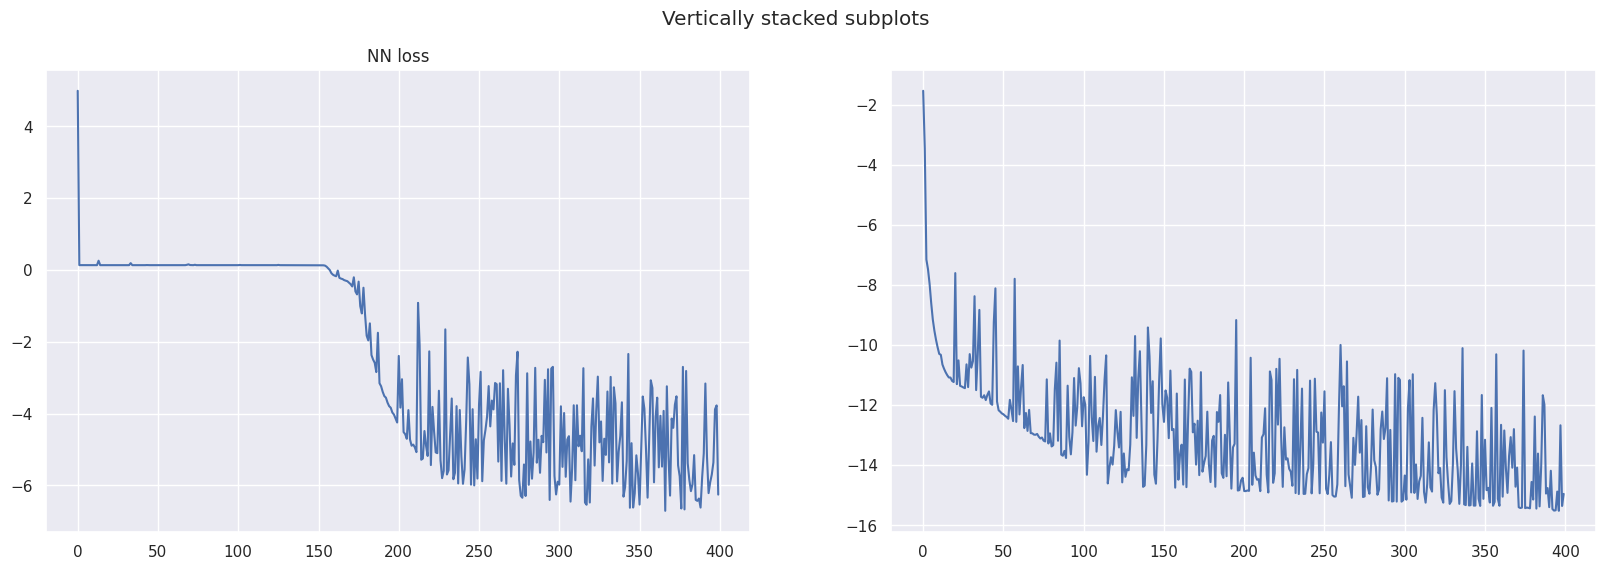

In [6]:
fig, axs = plt.subplots(1,2, figsize=(20,6))
axs[0].plot(losses[::200])
axs[1].plot(nn_losses[::200])
axs[0].set_title("PNN loss")
axs[0].set_title("NN loss")
fig.show()

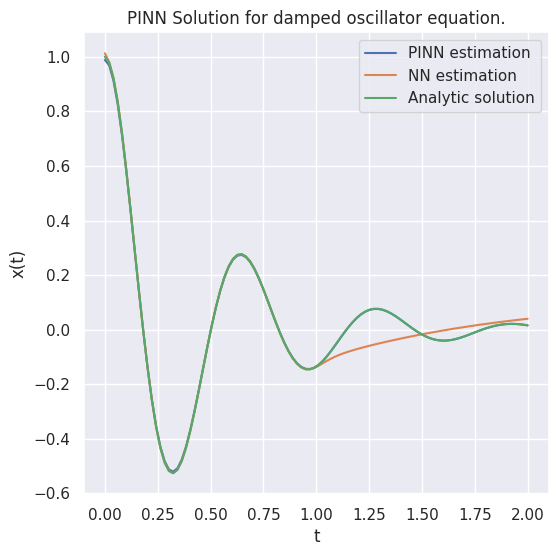

In [7]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)
x_test_nn = nn_model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_test_nn.detach().numpy(), label="NN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

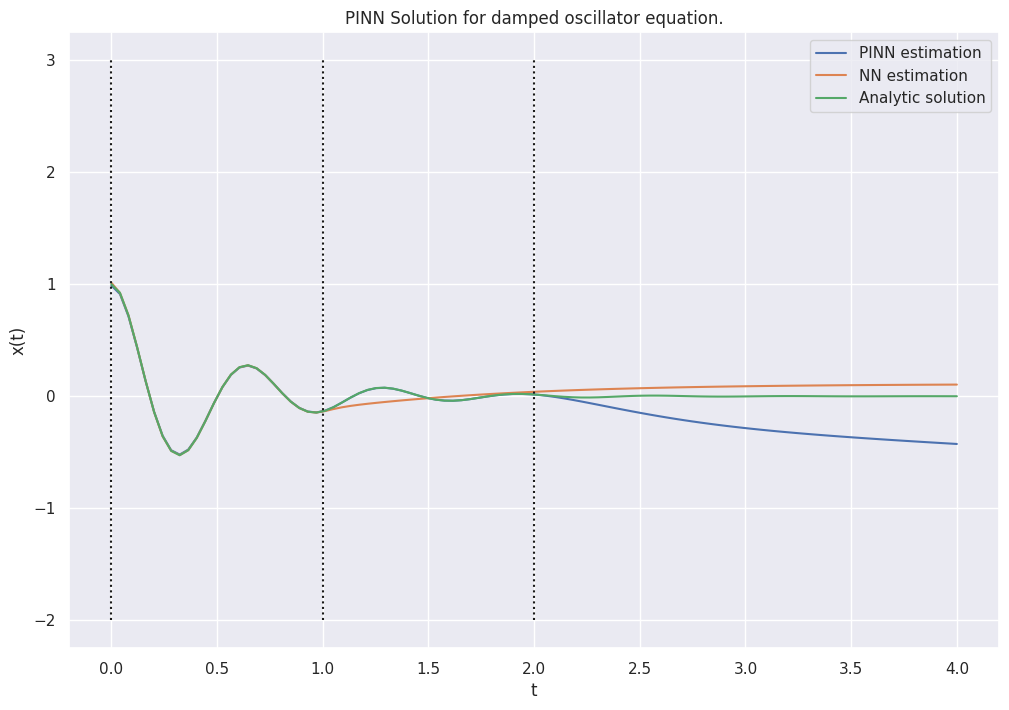

In [9]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 2*torch.linspace(0, 2, 100).reshape(-1, 1)
x_test = model(t_test)
x_test_nn = nn_model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(12,8))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_test_nn.detach().numpy(), label="NN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.vlines([0, 1, 2], [-2, -2, -2], [3, 3, 3], colors="k", linestyles="dotted")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()